In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os
cpu_num = os.cpu_count() // 2
print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [2]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
def onehot_label(cls: int):
    cls = torch.tensor(cls).long()
    return F.one_hot(cls, num_classes=10)

cifar_train = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=True,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

cifar_eval = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=False,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

Files already downloaded and verified
Files already downloaded and verified


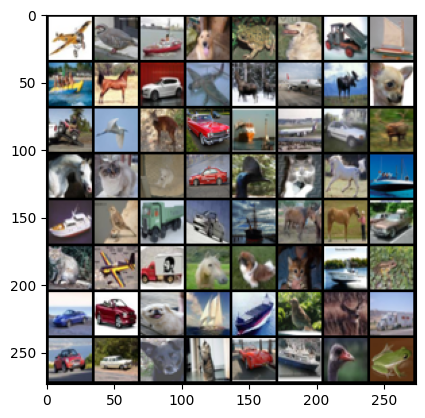

In [4]:
def random_grid(imgs, sz: int):
    samples_ix = torch.randint(low=0, high=len(imgs) - 1, size=(sz,))
    samples = imgs[samples_ix]
    grid = tu.make_grid(samples)
    return grid.permute(1, 2, 0)

tmps = torch.from_numpy(cifar_train.data)
tmps = random_grid(tmps.permute(0, 3, 1, 2), 64)
plt.imshow(tmps)

In [5]:
batchsize = 128

train_loader = tud.DataLoader(cifar_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(cifar_eval, batch_size=batchsize, shuffle=True)

In [6]:
class MyNn(nn.Module):
    def __init__(self, in_sz, out_sz, hidden_sz=128):
        super().__init__()
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.lin1 = nn.Linear(in_sz, hidden_sz, bias=True)
        self.lin2 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin3 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin4 = nn.Linear(hidden_sz, out_sz, bias=True)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = x.reshape(-1, self.in_sz)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        x = F.relu(x)
        x = self.lin4(x)
        return x

class MyCnn(nn.Module):
    def __init__(self, out_sz=10, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (32x32)
        self.conv1_1 = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)

        # (16x16)
        self.lin1 = nn.Linear(ch*2 * 16 * 16, 128, bias=True)
        self.lin2 = nn.Linear(128, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        x = F.relu(x)
        x = self.conv1_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = x.view(-1, self.channels*2 * 16 * 16)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x
        

In [13]:
from torchinfo import summary
# testmodel = MyCnn(out_sz=10, ch=16)
testmodel = MyNn(3 * 32 * 32, 10, hidden_sz=512)
test = cifar_train[0][0].float()
target = cifar_train[0][1].float()
print(target, testmodel(test))
summary(testmodel, (1, 3, 32, 32))

tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]) tensor([[ 0.1532, -3.3876, -5.0806, -2.9797,  0.2461,  8.3873, -3.8364, -5.5923,
          4.6958,  0.9690]], grad_fn=<AddmmBackward0>)


Layer (type:depth-idx)                   Output Shape              Param #
MyNn                                     [1, 10]                   --
├─Linear: 1-1                            [1, 512]                  1,573,376
├─Linear: 1-2                            [1, 512]                  262,656
├─Linear: 1-3                            [1, 512]                  262,656
├─Linear: 1-4                            [1, 10]                   5,130
Total params: 2,103,818
Trainable params: 2,103,818
Non-trainable params: 0
Total mult-adds (M): 2.10
Input size (MB): 0.01
Forward/backward pass size (MB): 0.01
Params size (MB): 8.42
Estimated Total Size (MB): 8.44

1.7343286275863647
1.5257434844970703
1.3573558330535889
1.3081098794937134
1.2614647150039673
1.1927766799926758
1.1803429126739502
1.1443285942077637
1.1541461944580078
1.1403512954711914
1.1451603174209595
1.1248877048492432
1.0912268161773682
1.1191984415054321
1.096348762512207
CPU times: user 2min 13s, sys: 9.54 s, total: 2min 23s
Wall time: 22.1 s


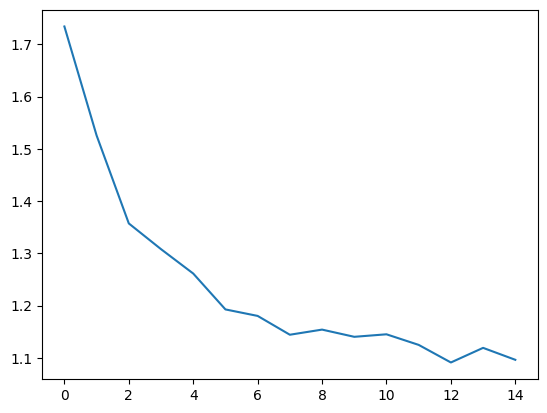

In [16]:
%%time
device='cuda'
# model = MyNn(3 * 32 * 32, 10, hidden_sz=512).to(device)
model = MyCnn(out_sz=10, ch=16).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
lossfn = nn.CrossEntropyLoss()
epochs = 15

loss_plot = []
for epoch in range(epochs):
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.float().to(device)

        outs = model(images)
        loss = lossfn(outs, targets.view(-1, 10))
        loss.backward()
        optimizer.step()

    losses = []
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.float().to(device)
            outs = model(images)
            loss = lossfn(outs, targets.view(-1, 10))
            losses.append(loss)
    epoch_loss = torch.Tensor(losses).mean().item()
    print(epoch_loss)
    loss_plot.append(epoch_loss)

plt.plot(loss_plot)

In [17]:
total = len(cifar_eval)
correct = 0
with torch.no_grad():
    for image, target in cifar_eval:
        pred = model(image.float().to(device))
        pred = F.softmax(pred, dim=1)
        if torch.allclose(pred.round().long().cpu(), target.cpu()):
            correct += 1
        
    print("{:.2f}% correct".format(100*correct/total))

54.94% correct
